# Métodos Tabulares (Versión 3)

La idea de este notebook es ir método por método, explicando:

- qué intenta aprender cada algoritmo
- cómo se implementa en este trabajo
- qué métricas usamos para validarlo
- y qué dicen los resultados obtenidos al ejecutar el código

El entorno sigue siendo `Taxi-v3`, pero ahora la comparación es completamente justa: mismo protocolo, mismas semillas, misma planificación de `epsilon`, misma evaluación greedy y la misma definición de éxito para todos los métodos.


## Entorno Taxi-v3

`Taxi-v3` es un entorno discreto con:

- `500` estados posibles
- `6` acciones discretas
- recompensa `-1` por paso
- recompensa `+20` cuando el taxi deja correctamente al pasajero
- penalización `-10` en acciones ilegales

La tarea real del agente no es solo llegar al objetivo alguna vez, sino aprender una política eficiente. Por eso en este notebook se van a separar dos cosas:

- el comportamiento durante el entrenamiento
- la calidad de la política greedy aprendida

Esa separación es especialmente importante en Monte Carlo off-policy, porque la política de comportamiento y la política objetivo no son la misma.


## Protocolo experimental

Estas son las condiciones exactas usadas en la validación:

- Entorno: `Taxi-v3`
- Semillas: [123, 231, 777, 2024, 31415]
- Episodios de entrenamiento por semilla: `10000`
- Factor de descuento: `gamma = 0.99`
- Exploración: `epsilon` desde `1.0` hasta `0.01` con decaimiento multiplicativo `0.9995`
- Evaluación greedy periódica: cada `250` episodios, usando `50` episodios de evaluación por punto
- Evaluación greedy final: `200` episodios por semilla
- Resumen de entrenamiento: últimos `1000` episodios
- Ventana de suavizado para gráficas: `200`
- SARSA y Q-Learning usan `alpha = 0.1`

Además, en esta implementación el éxito se mide con la señal real del entorno:

- `success = 1` cuando el episodio termina por `terminated`
- `success = 0` cuando el episodio termina por truncado

Esto evita el atajo de usar `reward > 0` como proxy, que en Taxi puede ser engañoso.


## Organización del código

La implementación de los métodos está en `entornos_complejos/src/tabular_taxi.py`.
En las celdas siguientes primero se fija la configuración, después se definen funciones auxiliares para resumir y graficar resultados, y luego se entrena cada método por separado.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "entornos_complejos").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from entornos_complejos.src.tabular_taxi import (
    ExperimentConfig,
    METHOD_COLORS,
    METHOD_LABELS,
    METHOD_ORDER,
    combine_method_results,
    run_method_experiment,
    save_results,
)

# Path donde se guardan los resultados de los experimentos en json 
RESULTS_PATH = ROOT / "entornos_complejos" / "artifacts" / "tabular_taxi_v3_results.json"

config_obj = ExperimentConfig(
    env_id="Taxi-v3",
    n_episodes=10000,
    gamma=0.99,
    alpha_td=0.10,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.9995,
    eval_every=250,
    eval_episodes=50,
    final_eval_episodes=200,
    rolling_window=200,
    summary_window=1000,
    seeds=(123, 231, 777, 2024, 31415),
)

# Ver la configuración del experimento
config_obj


ExperimentConfig(env_id='Taxi-v3', n_episodes=10000, gamma=0.99, alpha_td=0.1, epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.9995, eval_every=250, eval_episodes=50, final_eval_episodes=200, rolling_window=200, summary_window=1000, seeds=(123, 231, 777, 2024, 31415))

In [2]:
# Función de media móvil para suavizar las curvas de reward y longitud durante el entrenamiento
def media_movil(series, ventana):
    valores = np.asarray(series, dtype=float)
    kernel = np.ones(ventana, dtype=float) / ventana
    return np.convolve(valores, kernel, mode="valid")

# Función para generar un DataFrame resumen de un método específico a partir de los resultados del experimento
def method_summary_df(method_results, method):
    metrics = method_results["summary"][method]
    row = {
        "Método": METHOD_LABELS[method],
        "Train reward últimos 1000": metrics["train_reward_last_window_mean"],
        "Train reward std semillas": metrics["train_reward_last_window_std"],
        "Train longitud últimos 1000": metrics["train_length_last_window_mean"],
        "Train éxito real últimos 1000": metrics["train_success_last_window_mean"],
        "Eval greedy final": metrics["final_eval_reward_mean"],
        "Eval greedy std semillas": metrics["final_eval_reward_std_across_seeds"],
        "Eval greedy longitud": metrics["final_eval_length_mean"],
        "Eval greedy éxito real": metrics["final_eval_success_rate_mean"],
    }
    return pd.DataFrame([row]).set_index("Método").round(3)

# Función para generar las gráficas de evolución de entrenamiento y evaluación de un método específico a partir de los resultados del experimento
def plot_single_method(method_results, method):
    color = METHOD_COLORS[method]
    label = METHOD_LABELS[method]
    runs = method_results["runs"][method]
    curve = method_results["curves"][method]

    fig = plt.figure(figsize=(14, 10))
    fig.suptitle(f"{label} - Evolución del entrenamiento y de la política greedy", fontsize=13, fontweight="bold")
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

    # Gráfica de reward de entrenamiento (media móvil)
    ax1 = fig.add_subplot(gs[0, 0])
    train_reward_curves = [media_movil(run["rewards"], config_obj.rolling_window) for run in runs]
    min_len = min(len(curva) for curva in train_reward_curves)
    matrix = np.array([curva[:min_len] for curva in train_reward_curves])
    mean_curve = matrix.mean(axis=0)
    std_curve = matrix.std(axis=0)
    x = np.arange(config_obj.rolling_window // 2, config_obj.rolling_window // 2 + min_len)
    ax1.plot(x, mean_curve, color=color, lw=2)
    ax1.fill_between(x, mean_curve - std_curve, mean_curve + std_curve, color=color, alpha=0.15)
    ax1.set_title("Reward de entrenamiento (media móvil)")
    ax1.set_xlabel("Episodio")
    ax1.set_ylabel("Reward")
    ax1.grid(alpha=0.25)

    # Gráfica de longitud de episodio durante el entrenamiento (media móvil)
    ax2 = fig.add_subplot(gs[0, 1])
    train_length_curves = [media_movil(run["lengths"], config_obj.rolling_window) for run in runs]
    min_len = min(len(curva) for curva in train_length_curves)
    matrix = np.array([curva[:min_len] for curva in train_length_curves])
    mean_curve = matrix.mean(axis=0)
    std_curve = matrix.std(axis=0)
    x = np.arange(config_obj.rolling_window // 2, config_obj.rolling_window // 2 + min_len)
    ax2.plot(x, mean_curve, color=color, lw=2)
    ax2.fill_between(x, mean_curve - std_curve, mean_curve + std_curve, color=color, alpha=0.15)
    ax2.set_title("Longitud de episodio (media móvil)")
    ax2.set_xlabel("Episodio")
    ax2.set_ylabel("Pasos")
    ax2.grid(alpha=0.25)

    # Gráfica de reward en evaluación greedy
    ax3 = fig.add_subplot(gs[1, 0])
    eval_x = np.array(curve["eval_episodes"])
    eval_mean = np.array(curve["eval_reward_mean"])
    eval_std = np.array(curve["eval_reward_std_across_seeds"])
    ax3.plot(eval_x, eval_mean, color=color, lw=2, marker="o", ms=3)
    ax3.fill_between(eval_x, eval_mean - eval_std, eval_mean + eval_std, color=color, alpha=0.15)
    ax3.set_title("Reward en evaluación greedy")
    ax3.set_xlabel("Episodio")
    ax3.set_ylabel("Reward medio")
    ax3.grid(alpha=0.25)

    # Gráfica de tasa de éxito real en evaluación greedy
    ax4 = fig.add_subplot(gs[1, 1])
    success_mean = np.array(curve["eval_success_rate_mean"])
    success_std = np.array(curve["eval_success_rate_std_across_seeds"])
    ax4.plot(eval_x, success_mean, color=color, lw=2, marker="o", ms=3)
    ax4.fill_between(
        eval_x,
        np.clip(success_mean - success_std, 0.0, 1.0),
        np.clip(success_mean + success_std, 0.0, 1.0),
        color=color,
        alpha=0.15,
    )
    ax4.set_title("Éxito real en evaluación greedy")
    ax4.set_xlabel("Episodio")
    ax4.set_ylabel("Tasa de éxito")
    ax4.set_ylim(0, 1)
    ax4.grid(alpha=0.25)

    plt.show()


# Función para generar un DataFrame comparativo de resumen de todos los métodos a partir de los resultados del experimento
def comparative_summary_df(results):
    rows = []
    for method in results["ranking"]:
        metrics = results["summary"][method]
        rows.append(
            {
                "Método": METHOD_LABELS[method],
                "Train reward últimos 1000": metrics["train_reward_last_window_mean"],
                "Train longitud últimos 1000": metrics["train_length_last_window_mean"],
                "Train éxito real últimos 1000": metrics["train_success_last_window_mean"],
                "Eval greedy final": metrics["final_eval_reward_mean"],
                "Eval greedy std semillas": metrics["final_eval_reward_std_across_seeds"],
                "Eval greedy longitud": metrics["final_eval_length_mean"],
                "Eval greedy éxito real": metrics["final_eval_success_rate_mean"],
            }
        )
    return pd.DataFrame(rows).set_index("Método").round(3)

# Función para generar las gráficas comparativas de evolución de entrenamiento y evaluación de todos los métodos a partir de los resultados del experimento
def plot_comparative_results(results):
    fig = plt.figure(figsize=(15, 11))
    fig.suptitle("Taxi-v3: comparación global de métodos tabulares", fontsize=13, fontweight="bold")
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

    # Gráfica comparativa de reward de entrenamiento (media móvil)
    ax1 = fig.add_subplot(gs[0, 0])
    for method in results["ranking"]:
        color = METHOD_COLORS[method]
        curvas = [media_movil(run["rewards"], config_obj.rolling_window) for run in results["runs"][method]]
        min_len = min(len(curva) for curva in curvas)
        matrix = np.array([curva[:min_len] for curva in curvas])
        mean_curve = matrix.mean(axis=0)
        std_curve = matrix.std(axis=0)
        x = np.arange(config_obj.rolling_window // 2, config_obj.rolling_window // 2 + min_len)
        ax1.plot(x, mean_curve, lw=2, color=color, label=METHOD_LABELS[method])
        ax1.fill_between(x, mean_curve - std_curve, mean_curve + std_curve, color=color, alpha=0.12)
    ax1.set_title("Reward de entrenamiento (media móvil)")
    ax1.set_xlabel("Episodio")
    ax1.set_ylabel("Reward")
    ax1.grid(alpha=0.25)
    ax1.legend(fontsize=8)

    # Gráfica comparativa de longitud de episodio durante el entrenamiento (media móvil)
    ax2 = fig.add_subplot(gs[0, 1])
    for method in results["ranking"]:
        color = METHOD_COLORS[method]
        curvas = [media_movil(run["lengths"], config_obj.rolling_window) for run in results["runs"][method]]
        min_len = min(len(curva) for curva in curvas)
        matrix = np.array([curva[:min_len] for curva in curvas])
        mean_curve = matrix.mean(axis=0)
        std_curve = matrix.std(axis=0)
        x = np.arange(config_obj.rolling_window // 2, config_obj.rolling_window // 2 + min_len)
        ax2.plot(x, mean_curve, lw=2, color=color, label=METHOD_LABELS[method])
        ax2.fill_between(x, mean_curve - std_curve, mean_curve + std_curve, color=color, alpha=0.12)
    ax2.set_title("Longitud de episodio (media móvil)")
    ax2.set_xlabel("Episodio")
    ax2.set_ylabel("Pasos")
    ax2.grid(alpha=0.25)
    ax2.legend(fontsize=8)

    # Gráfica comparativa de reward en evaluación greedy
    ax3 = fig.add_subplot(gs[1, 0])
    for method in results["ranking"]:
        color = METHOD_COLORS[method]
        curve = results["curves"][method]
        x = np.array(curve["eval_episodes"])
        mean_curve = np.array(curve["eval_reward_mean"])
        std_curve = np.array(curve["eval_reward_std_across_seeds"])
        ax3.plot(x, mean_curve, lw=2, marker="o", ms=3, color=color, label=METHOD_LABELS[method])
        ax3.fill_between(x, mean_curve - std_curve, mean_curve + std_curve, color=color, alpha=0.12)
    ax3.set_title("Reward en evaluación greedy")
    ax3.set_xlabel("Episodio")
    ax3.set_ylabel("Reward medio")
    ax3.grid(alpha=0.25)
    ax3.legend(fontsize=8)
    
    # Gráfica comparativa de tasa de éxito real en evaluación greedy
    ax4 = fig.add_subplot(gs[1, 1])
    for method in results["ranking"]:
        color = METHOD_COLORS[method]
        curve = results["curves"][method]
        x = np.array(curve["eval_episodes"])
        mean_curve = np.array(curve["eval_success_rate_mean"])
        std_curve = np.array(curve["eval_success_rate_std_across_seeds"])
        ax4.plot(x, mean_curve, lw=2, marker="o", ms=3, color=color, label=METHOD_LABELS[method])
        ax4.fill_between(
            x,
            np.clip(mean_curve - std_curve, 0.0, 1.0),
            np.clip(mean_curve + std_curve, 0.0, 1.0),
            color=color,
            alpha=0.12,
        )
    ax4.set_title("Éxito real en evaluación greedy")
    ax4.set_xlabel("Episodio")
    ax4.set_ylabel("Tasa de éxito")
    ax4.set_ylim(0, 1)
    ax4.grid(alpha=0.25)
    ax4.legend(fontsize=8)

    plt.show()


In [3]:
from IPython.display import display, Markdown # Importar display y Markdown para mostrar resúmenes formateados en Jupyter Notebook

# Función para imprimir un resumen formateado de los resultados de un método específico a partir de los resultados del experimento
def print_method_summary(method_results, method):
    m = method_results["summary"][method]
    label = METHOD_LABELS[method]
    w = config_obj.summary_window
    fe = config_obj.final_eval_episodes
    ns = len(config_obj.seeds)
    sep = "─" * 55
    print(sep)
    print(f"  {label}")
    print(sep)
    print(f"Entrenamiento — últimos {w} episodios")
    print(f"  Reward     {m['train_reward_last_window_mean']:>10.3f}  ±  {m['train_reward_last_window_std']:.3f}")
    print(f"  Longitud   {m['train_length_last_window_mean']:>10.3f}")
    print(f"  Éxito real {100 * m['train_success_last_window_mean']:>9.1f}%")
    print(f"\nEvaluación greedy final  ({fe} episodios × {ns} semillas)")
    print(f"  Reward     {m['final_eval_reward_mean']:>10.3f}  ±  {m['final_eval_reward_std_across_seeds']:.3f}")
    print(f"  Longitud   {m['final_eval_length_mean']:>10.3f}")
    print(f"  Éxito real {100 * m['final_eval_success_rate_mean']:>9.1f}%")
    print(sep)

# Función para calcular el episodio de convergencia de un método específico a partir de los resultados del experimento, dado un umbral de éxito en evaluación greedy
def convergence_episode(method_results, method, threshold, metric="eval_success_rate_mean"):
    """First eval episode at which the metric first reached or exceeded the threshold. Returns None if never."""
    curves = method_results.get("curves", {}).get(method, {})
    if not curves:
        return None
    for ep, val in zip(curves["eval_episodes"], curves[metric]):
        if val >= threshold:
            return int(ep)
    return None


## 1. Monte Carlo on-policy (every-visit)

En Monte Carlo on-policy el agente aprende a partir de episodios completos generados por su propia política de exploración. Aquí usamos una política `epsilon-greedy` respecto a la tabla `Q`.

La implementación sigue estos pasos:

1. Se resetea el entorno con una semilla fija para ese episodio.
2. Se genera un episodio completo usando la política `epsilon-greedy`.
3. Se almacena toda la trayectoria `(s, a, r)`.
4. Al terminar el episodio se recorre la trayectoria hacia atrás para calcular el retorno acumulado `G`.
5. Como esta versión es *every-visit*, cada aparición de `(s, a)` se actualiza con media muestral.
6. Periódicamente se evalúa la política greedy aprendida, separada de la política exploratoria.

Esta versión se eligió porque es la variante on-policy más coherente de los notebooks previos y evita el error de mezclar `first-visit` con un recorrido invertido.


In [4]:
mc_on_results = run_method_experiment(config_obj, "mc_on_policy", verbose=True)

[run] MC On-Policy (Every-Visit) | seed=123
[run] MC On-Policy (Every-Visit) | seed=231
[run] MC On-Policy (Every-Visit) | seed=777
[run] MC On-Policy (Every-Visit) | seed=2024
[run] MC On-Policy (Every-Visit) | seed=31415


In [5]:
method_summary_df(mc_on_results, "mc_on_policy")

,Train reward últimos 1000,Train reward std semillas,Train longitud últimos 1000,Train éxito real últimos 1000,Eval greedy final,Eval greedy std semillas,Eval greedy longitud,Eval greedy éxito real
Método,,,,,,,,
MC On-Policy (Every-Visit),-130.918,10.162,134.791,0.375,-136.422,16.99,142.806,0.304


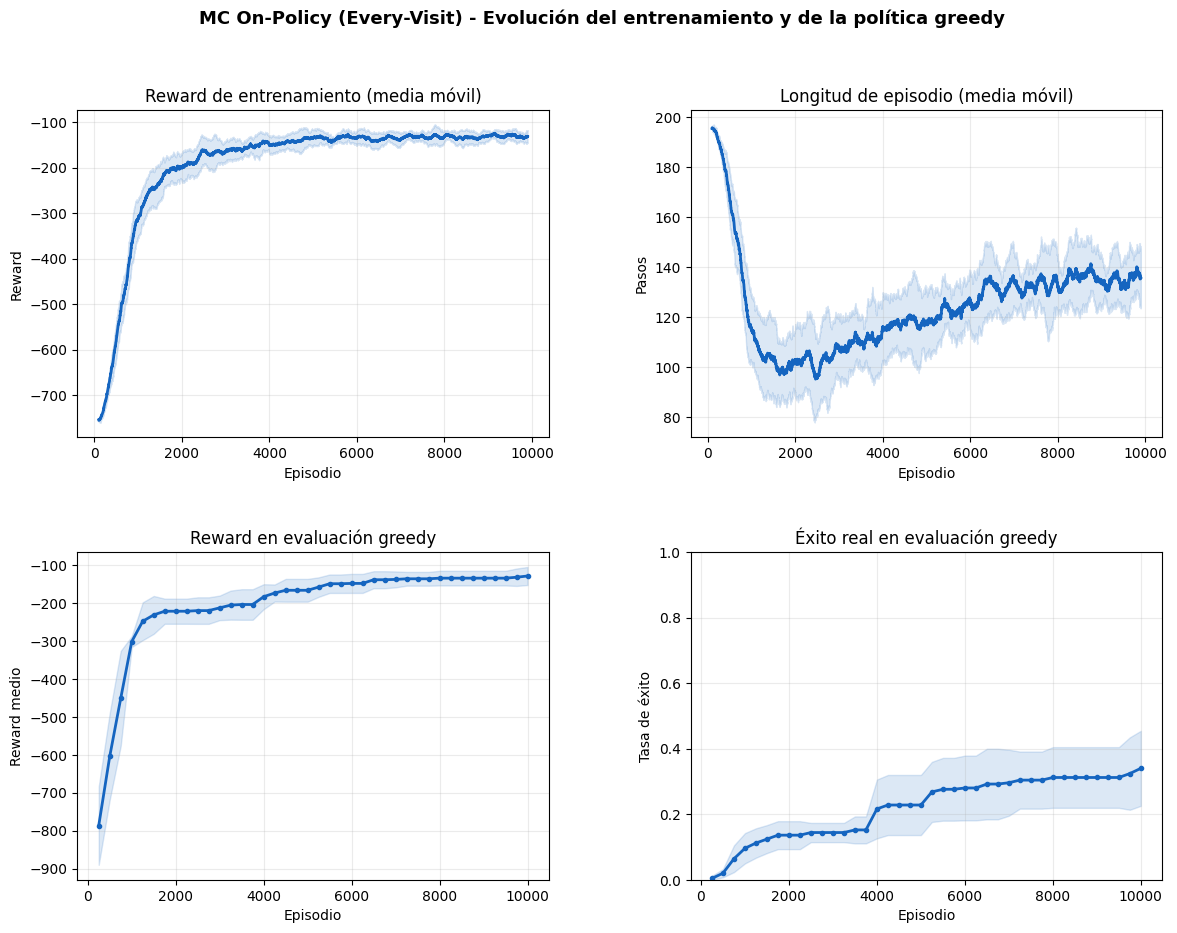

In [6]:
plot_single_method(mc_on_results, "mc_on_policy")


In [7]:
print_method_summary(mc_on_results, "mc_on_policy")

───────────────────────────────────────────────────────
  MC On-Policy (Every-Visit)
───────────────────────────────────────────────────────
Entrenamiento — últimos 1000 episodios
  Reward       -130.918  ±  10.162
  Longitud      134.791
  Éxito real      37.5%

Evaluación greedy final  (200 episodios × 5 semillas)
  Reward       -136.422  ±  16.990
  Longitud      142.806
  Éxito real      30.4%
───────────────────────────────────────────────────────


In [300]:
# Código de interpretación de resultados para el método MC On-Policy (Every-Visit) Markdown

_m = mc_on_results["summary"]["mc_on_policy"]
_curve = mc_on_results["curves"]["mc_on_policy"]
_sr_train = 100.0 * _m["train_success_last_window_mean"]
_sr_eval  = 100.0 * _m["final_eval_success_rate_mean"]
_sr_gap   = _sr_train - _sr_eval
_steps    = _m["final_eval_length_mean"]
_penalty  = _steps - 20.0

_conv_50 = convergence_episode(mc_on_results, "mc_on_policy", 0.50)
_conv_75 = convergence_episode(mc_on_results, "mc_on_policy", 0.75)
_conv_50_txt = f"episodio {_conv_50:,}" if _conv_50 else "no alcanzado en el experimento"
_conv_75_txt = f"episodio {_conv_75:,}" if _conv_75 else "no alcanzado en el experimento"
_pos_reward_ep = next((int(ep) for ep, reward in zip(_curve["eval_episodes"], _curve["eval_reward_mean"]) if reward > 0.0), None)
_pos_reward_txt = f"episodio {_pos_reward_ep:,}" if _pos_reward_ep else "no alcanzado en el experimento"

if _sr_gap > 5:
    _gap_note = (
        f"Existe una brecha de {_sr_gap:.1f} pp entre la tasa de éxito de entrenamiento ({_sr_train:.1f}%) "
        f"y la evaluación greedy ({_sr_eval:.1f}%), lo que sugiere que parte del rendimiento observado "
        "durante el aprendizaje sigue dependiendo de la exploración epsilon-greedy y no de una política robustamente consolidada."
    )
else:
    _gap_note = (
        f"La tasa de éxito de entrenamiento ({_sr_train:.1f}%) y la evaluación greedy ({_sr_eval:.1f}%) "
        "son próximas, lo que indica coherencia entre el comportamiento aprendido y el comportamiento evaluado sin exploración."
    )

display(Markdown(f"""
#### Interpretación — MC On-Policy (Every-Visit)

**Desempeño final de la política greedy.**
La política final obtiene un reward medio de **{_m["final_eval_reward_mean"]:.3f} ± {_m["final_eval_reward_std_across_seeds"]:.3f}**, con una longitud media de **{_steps:.1f} pasos** y una tasa de éxito de **{_sr_eval:.1f}%**.
Desde una perspectiva operativa, estos valores describen una mejora respecto al arranque, pero no una política eficiente: el coste acumulado de **{_steps:.1f}** pasos supera en **{_penalty:.1f}** puntos el bonus terminal de `+20`, por lo que el reward agregado permanece claramente negativo.

**Dinámica de aprendizaje observada en las curvas.**
En evaluación greedy, el reward medio pasa de **{_curve["eval_reward_mean"][0]:.1f}** en el episodio **{_curve["eval_episodes"][0]:,}** a **{_curve["eval_reward_mean"][-1]:.1f}** al final del experimento, mientras que la tasa de éxito sólo crece de **{100.0 * _curve["eval_success_rate_mean"][0]:.1f}%** a **{100.0 * _curve["eval_success_rate_mean"][-1]:.1f}%**.
El reward de evaluación no llega a ser positivo ({_pos_reward_txt}) y la tasa de éxito no alcanza el 50% ({_conv_50_txt}); en consecuencia, el gráfico muestra una mejora lenta y monotónica, pero sin evidencia de convergencia hacia una política competitiva dentro del presupuesto disponible.

**Coherencia entre entrenamiento y evaluación.**
{_gap_note}
Además, el reward medio de entrenamiento en los últimos **{config_obj.summary_window}** episodios es **{_m["train_reward_last_window_mean"]:.3f}**, muy próximo al reward greedy final, lo que confirma que el método termina estabilizándose en trayectorias largas y costosas más que en trayectorias óptimas.

**Lectura metodológica.**
El patrón observado es coherente con la naturaleza de Monte Carlo every-visit: la señal de actualización sólo se propaga al cierre de cada episodio y, en un entorno como `Taxi-v3`, eso retrasa notablemente la corrección de estados y acciones relevantes.
La desviación inter-semillas del reward final (**{_m["final_eval_reward_std_across_seeds"]:.3f}**) indica además una sensibilidad apreciable a la distribución de trayectorias visitadas.
"""))



#### Interpretación — MC On-Policy (Every-Visit)

**Desempeño final de la política greedy.**
La política final obtiene un reward medio de **-136.422 ± 16.990**, con una longitud media de **142.8 pasos** y una tasa de éxito de **30.4%**.
Desde una perspectiva operativa, estos valores describen una mejora respecto al arranque, pero no una política eficiente: el coste acumulado de **142.8** pasos supera en **122.8** puntos el bonus terminal de `+20`, por lo que el reward agregado permanece claramente negativo.

**Dinámica de aprendizaje observada en las curvas.**
En evaluación greedy, el reward medio pasa de **-786.7** en el episodio **250** a **-128.9** al final del experimento, mientras que la tasa de éxito sólo crece de **0.4%** a **34.0%**.
El reward de evaluación no llega a ser positivo (no alcanzado en el experimento) y la tasa de éxito no alcanza el 50% (no alcanzado en el experimento); en consecuencia, el gráfico muestra una mejora lenta y monotónica, pero sin evidencia de convergencia hacia una política competitiva dentro del presupuesto disponible.

**Coherencia entre entrenamiento y evaluación.**
Existe una brecha de 7.1 pp entre la tasa de éxito de entrenamiento (37.5%) y la evaluación greedy (30.4%), lo que sugiere que parte del rendimiento observado durante el aprendizaje sigue dependiendo de la exploración epsilon-greedy y no de una política robustamente consolidada.
Además, el reward medio de entrenamiento en los últimos **1000** episodios es **-130.918**, muy próximo al reward greedy final, lo que confirma que el método termina estabilizándose en trayectorias largas y costosas más que en trayectorias óptimas.

**Lectura metodológica.**
El patrón observado es coherente con la naturaleza de Monte Carlo every-visit: la señal de actualización sólo se propaga al cierre de cada episodio y, en un entorno como `Taxi-v3`, eso retrasa notablemente la corrección de estados y acciones relevantes.
La desviación inter-semillas del reward final (**16.990**) indica además una sensibilidad apreciable a la distribución de trayectorias visitadas.


## 2. Monte Carlo off-policy con Weighted Importance Sampling

Aquí ya no se aprende sobre la misma política con la que se explora, a diferencia de On--policy.

- La política de comportamiento sigue siendo `epsilon-greedy` y es la que genera los episodios.
- La política objetivo es la política greedy respecto a `Q`.

La implementación es la siguiente:

1. Se genera un episodio completo con la política de comportamiento.
2. En cada paso se guarda también `b(a|s)`, es decir, la probabilidad real de la acción bajo esa política de comportamiento.
3. Al terminar el episodio se recorre la trayectoria hacia atrás.
4. Se acumula el retorno `G` y el peso de importancia `W`.
5. Se actualiza `Q` con `Weighted Importance Sampling`.
6. Si la acción observada deja de coincidir con la política greedy objetivo, el barrido se corta.

Guardar explícitamente `b(a|s)` era una corrección importante frente a implementaciones anteriores, porque evita reconstruir esa probabilidad a posteriori con una `Q` ya modificada.


In [9]:
mc_off_results = run_method_experiment(config_obj, "mc_off_policy_weighted", verbose=True)

[run] MC Off-Policy (Weighted IS) | seed=123
[run] MC Off-Policy (Weighted IS) | seed=231
[run] MC Off-Policy (Weighted IS) | seed=777
[run] MC Off-Policy (Weighted IS) | seed=2024
[run] MC Off-Policy (Weighted IS) | seed=31415


In [10]:
method_summary_df(mc_off_results, "mc_off_policy_weighted")

,Train reward últimos 1000,Train reward std semillas,Train longitud últimos 1000,Train éxito real últimos 1000,Eval greedy final,Eval greedy std semillas,Eval greedy longitud,Eval greedy éxito real
Método,,,,,,,,
MC Off-Policy (Weighted IS),-7.678,4.551,25.58,0.939,-4.953,5.543,23.154,0.952


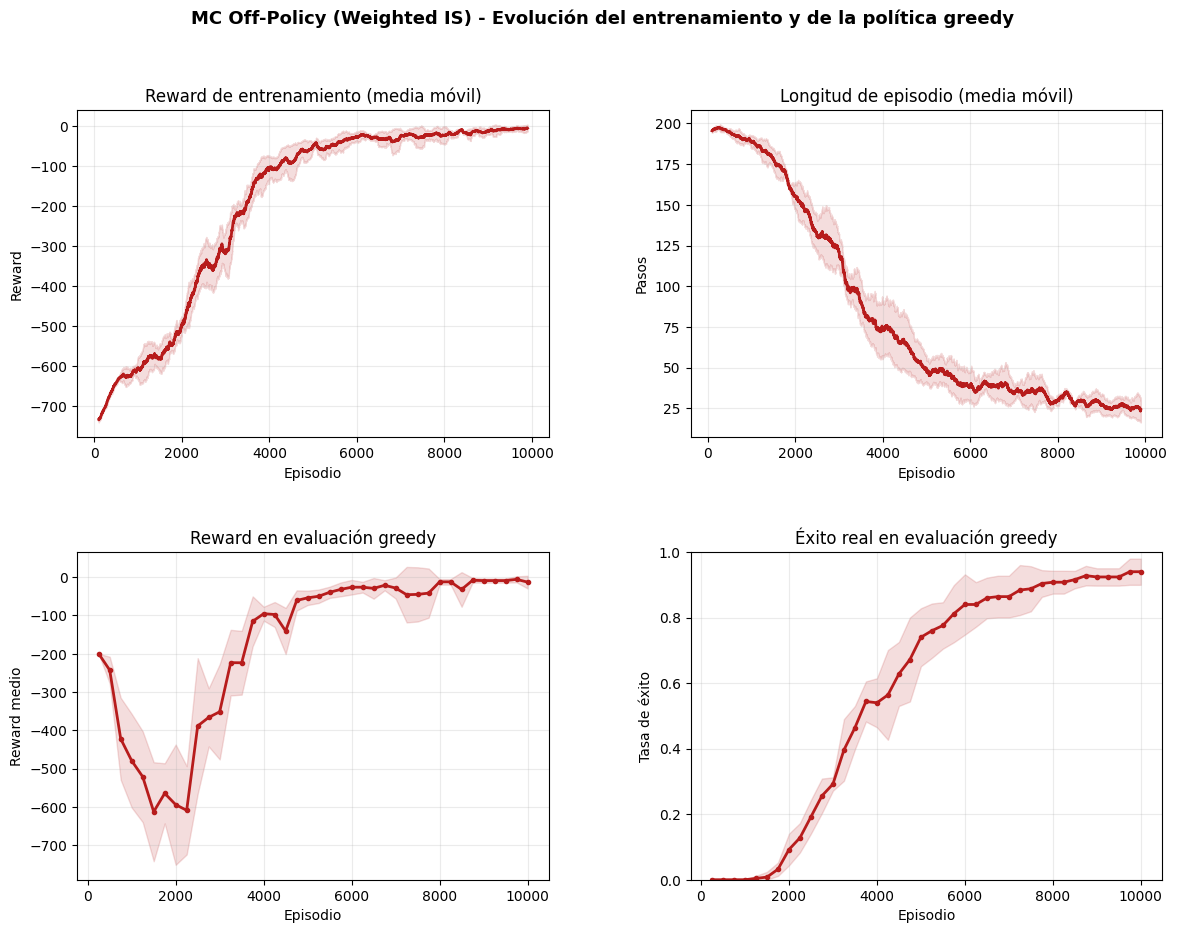

In [11]:
plot_single_method(mc_off_results, "mc_off_policy_weighted")

In [12]:
print_method_summary(mc_off_results, "mc_off_policy_weighted")

───────────────────────────────────────────────────────
  MC Off-Policy (Weighted IS)
───────────────────────────────────────────────────────
Entrenamiento — últimos 1000 episodios
  Reward         -7.678  ±  4.551
  Longitud       25.580
  Éxito real      93.9%

Evaluación greedy final  (200 episodios × 5 semillas)
  Reward         -4.953  ±  5.543
  Longitud       23.154
  Éxito real      95.2%
───────────────────────────────────────────────────────


In [301]:
# Código de interpretación de resultados para el método MC Off-Policy (Weighted Importance Sampling) Markdown
_mon   = mc_on_results["summary"]["mc_on_policy"]
_moff  = mc_off_results["summary"]["mc_off_policy_weighted"]
_curve = mc_off_results["curves"]["mc_off_policy_weighted"]

_reward_delta  = _moff["final_eval_reward_mean"] - _mon["final_eval_reward_mean"]
_length_delta  = _mon["final_eval_length_mean"]  - _moff["final_eval_length_mean"]
_success_delta = 100.0 * (_moff["final_eval_success_rate_mean"] - _mon["final_eval_success_rate_mean"])

_sr_eval  = 100.0 * _moff["final_eval_success_rate_mean"]
_steps    = _moff["final_eval_length_mean"]
_net_gain = 20.0 - _steps

_conv_75 = convergence_episode(mc_off_results, "mc_off_policy_weighted", 0.75)
_conv_90 = convergence_episode(mc_off_results, "mc_off_policy_weighted", 0.90)
_conv_99 = convergence_episode(mc_off_results, "mc_off_policy_weighted", 0.99)
_conv_75_txt = f"episodio {_conv_75:,}" if _conv_75 else "no alcanzado en el experimento"
_conv_90_txt = f"episodio {_conv_90:,}" if _conv_90 else "no alcanzado en el experimento"
_conv_99_txt = f"episodio {_conv_99:,}" if _conv_99 else "no alcanzado en el experimento"
_pos_reward_ep = next((int(ep) for ep, reward in zip(_curve["eval_episodes"], _curve["eval_reward_mean"]) if reward > 0.0), None)
_pos_reward_txt = f"episodio {_pos_reward_ep:,}" if _pos_reward_ep else "no alcanzado en el experimento"
_min_reward_idx = int(np.argmin(np.array(_curve["eval_reward_mean"])))
_min_reward = float(_curve["eval_reward_mean"][_min_reward_idx])
_min_reward_ep = int(_curve["eval_episodes"][_min_reward_idx])

display(Markdown(f"""
#### Interpretación — MC Off-Policy (Weighted Importance Sampling)

**Desempeño final y mejora respecto a MC on-policy.**
El método alcanza un reward greedy final de **{_moff["final_eval_reward_mean"]:.3f} ± {_moff["final_eval_reward_std_across_seeds"]:.3f}**, con **{_steps:.1f} pasos** de media y **{_sr_eval:.1f}%** de éxito greedy.
En comparación con MC on-policy, la mejora es sustantiva: **{_reward_delta:+.3f} puntos** de reward, **{_length_delta:.1f} pasos** menos por episodio y **{_success_delta:+.1f} pp** adicionales de éxito.

**Dinámica de aprendizaje observada en las curvas.**
El gráfico muestra una fase transitoria larga y más inestable que la de los métodos TD. En evaluación greedy, el reward cae hasta **{_min_reward:.1f}** alrededor del episodio **{_min_reward_ep:,}** antes de iniciar una recuperación sostenida.
Posteriormente, la tasa de éxito supera el **75%** en el {_conv_75_txt} y el **90%** en el {_conv_90_txt}, pero no alcanza el **99%** ({_conv_99_txt}). Esto indica una política claramente mejor que la de MC on-policy, aunque todavía lejos de una convergencia rápida y limpia.

**Relación entre éxito y reward.**
La combinación de **95.2%** de éxito con reward negativo no es contradictoria: un episodio exitoso típico genera **{_net_gain:.1f} puntos netos** antes de considerar penalizaciones adicionales, porque la longitud media de **{_steps:.1f} pasos** sigue por encima del umbral de 20 pasos necesario para producir reward positivo.
En consecuencia, el reward de evaluación nunca llega a ser positivo ({_pos_reward_txt}) pese a la alta tasa de éxito final.

**Estabilidad e interpretación metodológica.**
La desviación inter-semillas del reward final (**{_moff["final_eval_reward_std_across_seeds"]:.3f}**) es claramente menor que la de MC on-policy (**{_mon["final_eval_reward_std_across_seeds"]:.3f}**), lo que sugiere una mejora de estabilidad respecto a la variante on-policy.
No obstante, la banda de incertidumbre sigue siendo ancha y el aprendizaje continúa siendo sensible a la trayectoria efectiva de muestreo: el truncamiento del barrido hacia atrás en Weighted IS hace que el número efectivo de actualizaciones varíe considerablemente entre episodios y entre semillas.
"""))



#### Interpretación — MC Off-Policy (Weighted Importance Sampling)

**Desempeño final y mejora respecto a MC on-policy.**
El método alcanza un reward greedy final de **-4.953 ± 5.543**, con **23.2 pasos** de media y **95.2%** de éxito greedy.
En comparación con MC on-policy, la mejora es sustantiva: **+131.469 puntos** de reward, **119.7 pasos** menos por episodio y **+64.8 pp** adicionales de éxito.

**Dinámica de aprendizaje observada en las curvas.**
El gráfico muestra una fase transitoria larga y más inestable que la de los métodos TD. En evaluación greedy, el reward cae hasta **-612.5** alrededor del episodio **1,500** antes de iniciar una recuperación sostenida.
Posteriormente, la tasa de éxito supera el **75%** en el episodio 5,250 y el **90%** en el episodio 7,750, pero no alcanza el **99%** (no alcanzado en el experimento). Esto indica una política claramente mejor que la de MC on-policy, aunque todavía lejos de una convergencia rápida y limpia.

**Relación entre éxito y reward.**
La combinación de **95.2%** de éxito con reward negativo no es contradictoria: un episodio exitoso típico genera **-3.2 puntos netos** antes de considerar penalizaciones adicionales, porque la longitud media de **23.2 pasos** sigue por encima del umbral de 20 pasos necesario para producir reward positivo.
En consecuencia, el reward de evaluación nunca llega a ser positivo (no alcanzado en el experimento) pese a la alta tasa de éxito final.

**Estabilidad e interpretación metodológica.**
La desviación inter-semillas del reward final (**5.543**) es claramente menor que la de MC on-policy (**16.990**), lo que sugiere una mejora de estabilidad respecto a la variante on-policy.
No obstante, la banda de incertidumbre sigue siendo ancha y el aprendizaje continúa siendo sensible a la trayectoria efectiva de muestreo: el truncamiento del barrido hacia atrás en Weighted IS hace que el número efectivo de actualizaciones varíe considerablemente entre episodios y entre semillas.


## 3. SARSA tabular

SARSA es un método TD on-policy. A diferencia de Monte Carlo, no espera al final del episodio para corregir la tabla `Q`, sino que actualiza en cada transición usando la acción siguiente realmente elegida por la política actual.

Implementación en cada paso:

1. Se elige una acción `a` con la política `epsilon-greedy`.
2. Se observa `(s, a, r, s')`.
3. Si el episodio no ha terminado, se elige `a'` en `s'`.
4. Se aplica la actualización:

`Q(s,a) <- Q(s,a) + alpha * [r + gamma * Q(s',a') - Q(s,a)]`

Como es on-policy, la misma política que explora es la que se evalúa durante el aprendizaje.


In [14]:
sarsa_results = run_method_experiment(config_obj, "sarsa", verbose=True)

[run] SARSA | seed=123
[run] SARSA | seed=231
[run] SARSA | seed=777
[run] SARSA | seed=2024
[run] SARSA | seed=31415


In [15]:
method_summary_df(sarsa_results, "sarsa")

,Train reward últimos 1000,Train reward std semillas,Train longitud últimos 1000,Train éxito real últimos 1000,Eval greedy final,Eval greedy std semillas,Eval greedy longitud,Eval greedy éxito real
Método,,,,,,,,
SARSA,7.387,0.133,13.251,1.0,7.722,0.157,13.278,1.0


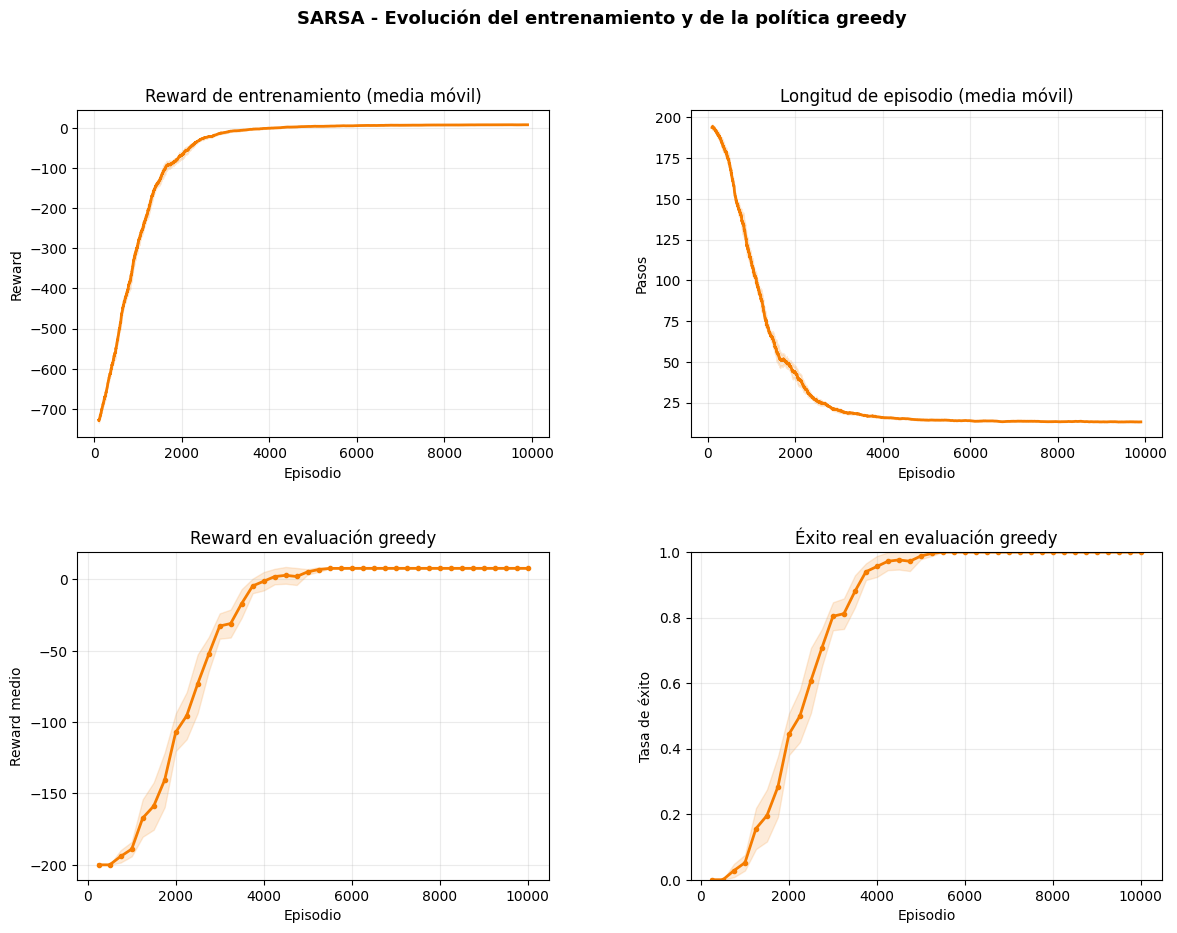

In [16]:
plot_single_method(sarsa_results, "sarsa")

In [17]:
print_method_summary(sarsa_results, "sarsa")

───────────────────────────────────────────────────────
  SARSA
───────────────────────────────────────────────────────
Entrenamiento — últimos 1000 episodios
  Reward          7.387  ±  0.133
  Longitud       13.251
  Éxito real     100.0%

Evaluación greedy final  (200 episodios × 5 semillas)
  Reward          7.722  ±  0.157
  Longitud       13.278
  Éxito real     100.0%
───────────────────────────────────────────────────────


In [302]:
# Código de interpretación de resultados para el método SARSA (TD on-policy) Markdown

_mon   = mc_on_results["summary"]["mc_on_policy"]
_moff  = mc_off_results["summary"]["mc_off_policy_weighted"]
_sar   = sarsa_results["summary"]["sarsa"]
_curve = sarsa_results["curves"]["sarsa"]

_reward_vs_moff  = _sar["final_eval_reward_mean"]  - _moff["final_eval_reward_mean"]
_length_vs_moff  = _moff["final_eval_length_mean"] - _sar["final_eval_length_mean"]
_success_vs_moff = 100.0 * (_sar["final_eval_success_rate_mean"] - _moff["final_eval_success_rate_mean"])

_sr_eval = 100.0 * _sar["final_eval_success_rate_mean"]
_steps   = _sar["final_eval_length_mean"]

_conv_90 = convergence_episode(sarsa_results, "sarsa", 0.90)
_conv_99 = convergence_episode(sarsa_results, "sarsa", 0.99)
_conv_90_txt = f"episodio {_conv_90:,}" if _conv_90 else "no alcanzado en el experimento"
_conv_99_txt = f"episodio {_conv_99:,}" if _conv_99 else "no alcanzado en el experimento"
_pos_reward_ep = next((int(ep) for ep, reward in zip(_curve["eval_episodes"], _curve["eval_reward_mean"]) if reward > 0.0), None)
_pos_reward_txt = f"episodio {_pos_reward_ep:,}" if _pos_reward_ep else "no alcanzado en el experimento"

display(Markdown(f"""
#### Interpretación — SARSA (TD on-policy)

**Desempeño final de la política greedy.**
SARSA alcanza un reward final de **{_sar["final_eval_reward_mean"]:.3f} ± {_sar["final_eval_reward_std_across_seeds"]:.3f}**, con una longitud media de **{_steps:.1f} pasos** y **{_sr_eval:.1f}%** de éxito greedy.
Frente al mejor método Monte Carlo, esto supone una mejora de **{_reward_vs_moff:+.3f} puntos** en reward, una reducción de **{_length_vs_moff:.1f} pasos** por episodio y **{_success_vs_moff:+.1f} pp** adicionales de éxito.

**Dinámica de aprendizaje observada en las curvas.**
El patrón gráfico es claramente distinto al de Monte Carlo: la longitud de episodio cae con rapidez hasta el entorno de **13 pasos**, el reward de evaluación se vuelve positivo en el {_pos_reward_txt}, la tasa de éxito supera el **90%** en el {_conv_90_txt} y alcanza el **99%** en el {_conv_99_txt}.
Además, la banda de incertidumbre es estrecha durante la fase final, lo que sugiere una convergencia homogénea entre semillas.

**Coherencia entre entrenamiento y evaluación.**
El reward medio de entrenamiento en los últimos **{config_obj.summary_window}** episodios es **{_sar["train_reward_last_window_mean"]:.3f}**, muy próximo al reward greedy final, y la tasa de éxito es del **100%** tanto en entrenamiento como en evaluación.
Esta proximidad entre métricas indica que la política aprendida es estable y que el comportamiento observado durante el aprendizaje refleja adecuadamente la política final.

**Interpretación metodológica.**
El resultado es consistente con la naturaleza TD on-policy de SARSA: al actualizar la tabla `Q` en cada transición, el método propaga información útil de manera mucho más densa que Monte Carlo y reduce drásticamente el coste de muestra necesario para aproximarse a la política óptima.
La baja desviación del reward de entrenamiento (**{_sar["train_reward_last_window_std"]:.3f}**) refuerza la idea de una convergencia robusta y reproducible.
"""))



#### Interpretación — SARSA (TD on-policy)

**Desempeño final de la política greedy.**
SARSA alcanza un reward final de **7.722 ± 0.157**, con una longitud media de **13.3 pasos** y **100.0%** de éxito greedy.
Frente al mejor método Monte Carlo, esto supone una mejora de **+12.675 puntos** en reward, una reducción de **9.9 pasos** por episodio y **+4.8 pp** adicionales de éxito.

**Dinámica de aprendizaje observada en las curvas.**
El patrón gráfico es claramente distinto al de Monte Carlo: la longitud de episodio cae con rapidez hasta el entorno de **13 pasos**, el reward de evaluación se vuelve positivo en el episodio 4,250, la tasa de éxito supera el **90%** en el episodio 3,750 y alcanza el **99%** en el episodio 5,250.
Además, la banda de incertidumbre es estrecha durante la fase final, lo que sugiere una convergencia homogénea entre semillas.

**Coherencia entre entrenamiento y evaluación.**
El reward medio de entrenamiento en los últimos **1000** episodios es **7.387**, muy próximo al reward greedy final, y la tasa de éxito es del **100%** tanto en entrenamiento como en evaluación.
Esta proximidad entre métricas indica que la política aprendida es estable y que el comportamiento observado durante el aprendizaje refleja adecuadamente la política final.

**Interpretación metodológica.**
El resultado es consistente con la naturaleza TD on-policy de SARSA: al actualizar la tabla `Q` en cada transición, el método propaga información útil de manera mucho más densa que Monte Carlo y reduce drásticamente el coste de muestra necesario para aproximarse a la política óptima.
La baja desviación del reward de entrenamiento (**0.133**) refuerza la idea de una convergencia robusta y reproducible.


## 4. Q-Learning tabular

Q-Learning es off-policy. La política de comportamiento sigue siendo `epsilon-greedy`, pero la corrección TD usa el mejor valor estimado del siguiente estado, no la acción realmente muestreada.

La actualización es:

`Q(s,a) <- Q(s,a) + alpha * [r + gamma * max_a' Q(s',a') - Q(s,a)]`

En este tipo de problemas debería ser bueno porque:

- actualiza en cada paso
- propaga valores rápidamente
- y optimiza de forma más agresiva que SARSA


In [19]:
q_learning_results = run_method_experiment(config_obj, "q_learning", verbose=True)

[run] Q-Learning | seed=123
[run] Q-Learning | seed=231
[run] Q-Learning | seed=777
[run] Q-Learning | seed=2024
[run] Q-Learning | seed=31415


In [20]:
method_summary_df(q_learning_results, "q_learning")

,Train reward últimos 1000,Train reward std semillas,Train longitud últimos 1000,Train éxito real últimos 1000,Eval greedy final,Eval greedy std semillas,Eval greedy longitud,Eval greedy éxito real
Método,,,,,,,,
Q-Learning,7.499,0.124,13.17,1.0,7.788,0.157,13.212,1.0


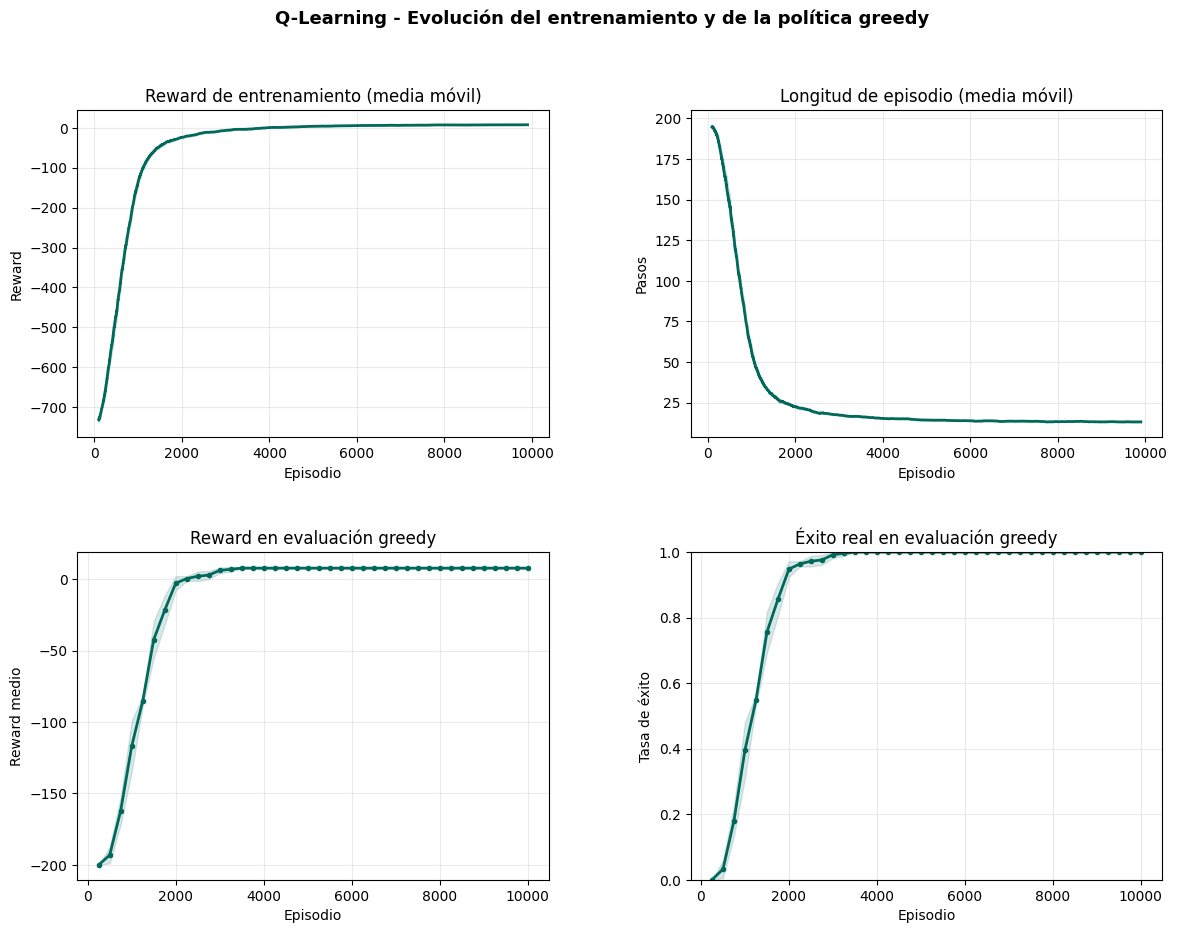

In [21]:
plot_single_method(q_learning_results, "q_learning")

In [22]:
print_method_summary(q_learning_results, "q_learning")

───────────────────────────────────────────────────────
  Q-Learning
───────────────────────────────────────────────────────
Entrenamiento — últimos 1000 episodios
  Reward          7.499  ±  0.124
  Longitud       13.170
  Éxito real     100.0%

Evaluación greedy final  (200 episodios × 5 semillas)
  Reward          7.788  ±  0.157
  Longitud       13.212
  Éxito real     100.0%
───────────────────────────────────────────────────────


In [303]:
# Código de interpretación de resultados para el método Q-Learning (TD off-policy) Markdown
_sar   = sarsa_results["summary"]["sarsa"]
_ql    = q_learning_results["summary"]["q_learning"]
_curve = q_learning_results["curves"]["q_learning"]

_reward_delta = _ql["final_eval_reward_mean"] - _sar["final_eval_reward_mean"]
_length_sar   = _sar["final_eval_length_mean"]
_length_ql    = _ql["final_eval_length_mean"]
_sr_eval      = 100.0 * _ql["final_eval_success_rate_mean"]

_conv_90 = convergence_episode(q_learning_results, "q_learning", 0.90)
_conv_99 = convergence_episode(q_learning_results, "q_learning", 0.99)
_conv_90_txt = f"episodio {_conv_90:,}" if _conv_90 else "no alcanzado en el experimento"
_conv_99_txt = f"episodio {_conv_99:,}" if _conv_99 else "no alcanzado en el experimento"
_pos_reward_ep = next((int(ep) for ep, reward in zip(_curve["eval_episodes"], _curve["eval_reward_mean"]) if reward > 0.0), None)
_pos_reward_txt = f"episodio {_pos_reward_ep:,}" if _pos_reward_ep else "no alcanzado en el experimento"

_sarsa_by_seed = {run["seed"]: run["final_eval_reward_mean"] for run in sarsa_results["runs"]["sarsa"]}
_ql_by_seed = {run["seed"]: run["final_eval_reward_mean"] for run in q_learning_results["runs"]["q_learning"]}
_seed_deltas = [_ql_by_seed[seed] - _sarsa_by_seed[seed] for seed in sorted(_ql_by_seed)]
_seed_delta_min = min(_seed_deltas)
_seed_delta_max = max(_seed_deltas)

if all(delta > 0 for delta in _seed_deltas):
    _seed_note = (
        f"La ventaja de Q-Learning aparece en las {len(_seed_deltas)} semillas: "
        f"los incrementos de reward van de {_seed_delta_min:+.3f} a {_seed_delta_max:+.3f} puntos."
    )
else:
    _seed_note = "La ventaja agregada es pequeña y no es uniforme en todas las semillas."

display(Markdown(f"""
#### Interpretación — Q-Learning (TD off-policy)

**Desempeño final y comparación directa con SARSA.**
Q-Learning obtiene el mejor reward final del experimento: **{_ql["final_eval_reward_mean"]:.3f} ± {_ql["final_eval_reward_std_across_seeds"]:.3f}**, con una longitud media de **{_length_ql:.1f} pasos** y **{_sr_eval:.1f}%** de éxito greedy.
La diferencia frente a SARSA es pequeña en magnitud absoluta (**{_reward_delta:+.3f} puntos** de reward y **{_length_sar - _length_ql:.3f} pasos** menos por episodio), pero no es aleatoria: {_seed_note}

**Dinámica de aprendizaje observada en las curvas.**
En el gráfico comparativo, Q-Learning es el método que acelera más rápido la mejora inicial: el reward greedy se vuelve positivo en el {_pos_reward_txt}, la tasa de éxito supera el **90%** en el {_conv_90_txt} y alcanza el **99%** en el {_conv_99_txt}.
La curva de longitud de episodio también desciende antes que la de SARSA y se estabiliza antes en el entorno de **13.2 pasos**, lo que indica una mayor eficiencia de muestra en la fase temprana del entrenamiento.

**Robustez de la solución final.**
La desviación inter-semillas del reward final (**{_ql["final_eval_reward_std_across_seeds"]:.3f}**) es prácticamente idéntica a la de SARSA (**{_sar["final_eval_reward_std_across_seeds"]:.3f}**), por lo que la ventaja de Q-Learning no se explica por una mayor dispersión ni por unas pocas ejecuciones excepcionalmente favorables.

**Interpretación metodológica.**
El patrón observado es coherente con la naturaleza off-policy de Q-Learning: al construir el objetivo TD con `max_a Q(s', a)`, el método propaga de forma más agresiva el valor de las mejores acciones y desacopla la actualización de la acción efectivamente muestreada.
En `Taxi-v3`, donde la política final es casi determinista y muy eficiente, esa agresividad adicional se traduce en una convergencia más rápida y en una ventaja final pequeña, pero sistemática, sobre SARSA.
"""))



#### Interpretación — Q-Learning (TD off-policy)

**Desempeño final y comparación directa con SARSA.**
Q-Learning obtiene el mejor reward final del experimento: **7.788 ± 0.157**, con una longitud media de **13.2 pasos** y **100.0%** de éxito greedy.
La diferencia frente a SARSA es pequeña en magnitud absoluta (**+0.066 puntos** de reward y **0.066 pasos** menos por episodio), pero no es aleatoria: La ventaja de Q-Learning aparece en las 5 semillas: los incrementos de reward van de +0.050 a +0.080 puntos.

**Dinámica de aprendizaje observada en las curvas.**
En el gráfico comparativo, Q-Learning es el método que acelera más rápido la mejora inicial: el reward greedy se vuelve positivo en el episodio 2,250, la tasa de éxito supera el **90%** en el episodio 2,000 y alcanza el **99%** en el episodio 3,000.
La curva de longitud de episodio también desciende antes que la de SARSA y se estabiliza antes en el entorno de **13.2 pasos**, lo que indica una mayor eficiencia de muestra en la fase temprana del entrenamiento.

**Robustez de la solución final.**
La desviación inter-semillas del reward final (**0.157**) es prácticamente idéntica a la de SARSA (**0.157**), por lo que la ventaja de Q-Learning no se explica por una mayor dispersión ni por unas pocas ejecuciones excepcionalmente favorables.

**Interpretación metodológica.**
El patrón observado es coherente con la naturaleza off-policy de Q-Learning: al construir el objetivo TD con `max_a Q(s', a)`, el método propaga de forma más agresiva el valor de las mejores acciones y desacopla la actualización de la acción efectivamente muestreada.
En `Taxi-v3`, donde la política final es casi determinista y muy eficiente, esa agresividad adicional se traduce en una convergencia más rápida y en una ventaja final pequeña, pero sistemática, sobre SARSA.


## 5. Comparativa Global de algoritmos

Metodología comparativa seguida:

- guardar el experimento completo
- construir la tabla final agregada
- dibujar las gráficas comparativas
- analizar los resultados obtenidos


In [24]:
# Combinar todos los resultados en un único diccionario estructurado y guardarlo en un archivo JSON
all_results = combine_method_results(
    config_obj,
    {
        "mc_on_policy": mc_on_results,
        "mc_off_policy_weighted": mc_off_results,
        "sarsa": sarsa_results,
        "q_learning": q_learning_results,
    },
)
save_results(all_results, RESULTS_PATH)
print(f"Resultados guardados en: {RESULTS_PATH}")


Resultados guardados en: /home/christianr/extML/entornos_complejos/artifacts/tabular_taxi_v3_results.json


In [25]:
comparative_summary_df(all_results)

,Train reward últimos 1000,Train longitud últimos 1000,Train éxito real últimos 1000,Eval greedy final,Eval greedy std semillas,Eval greedy longitud,Eval greedy éxito real
Método,,,,,,,
Q-Learning,7.499,13.170,1.000,7.788,0.157,13.212,1.000
SARSA,7.387,13.251,1.000,7.722,0.157,13.278,1.000
MC Off-Policy (Weighted IS),-7.678,25.580,0.939,-4.953,5.543,23.154,0.952
MC On-Policy (Every-Visit),-130.918,134.791,0.375,-136.422,16.990,142.806,0.304


In [26]:
# Imprimir un ranking de métodos basado en el reward greedy final, mostrando el reward medio y su desviación entre semillas para cada método
for idx, method in enumerate(all_results["ranking"], start=1):
    metrics = all_results["summary"][method]
    print(
        f"{idx}. {METHOD_LABELS[method]} -> "
        f"eval greedy final = {metrics['final_eval_reward_mean']:.3f} +/- "
        f"{metrics['final_eval_reward_std_across_seeds']:.3f}"
    )


1. Q-Learning -> eval greedy final = 7.788 +/- 0.157
2. SARSA -> eval greedy final = 7.722 +/- 0.157
3. MC Off-Policy (Weighted IS) -> eval greedy final = -4.953 +/- 5.543
4. MC On-Policy (Every-Visit) -> eval greedy final = -136.422 +/- 16.990


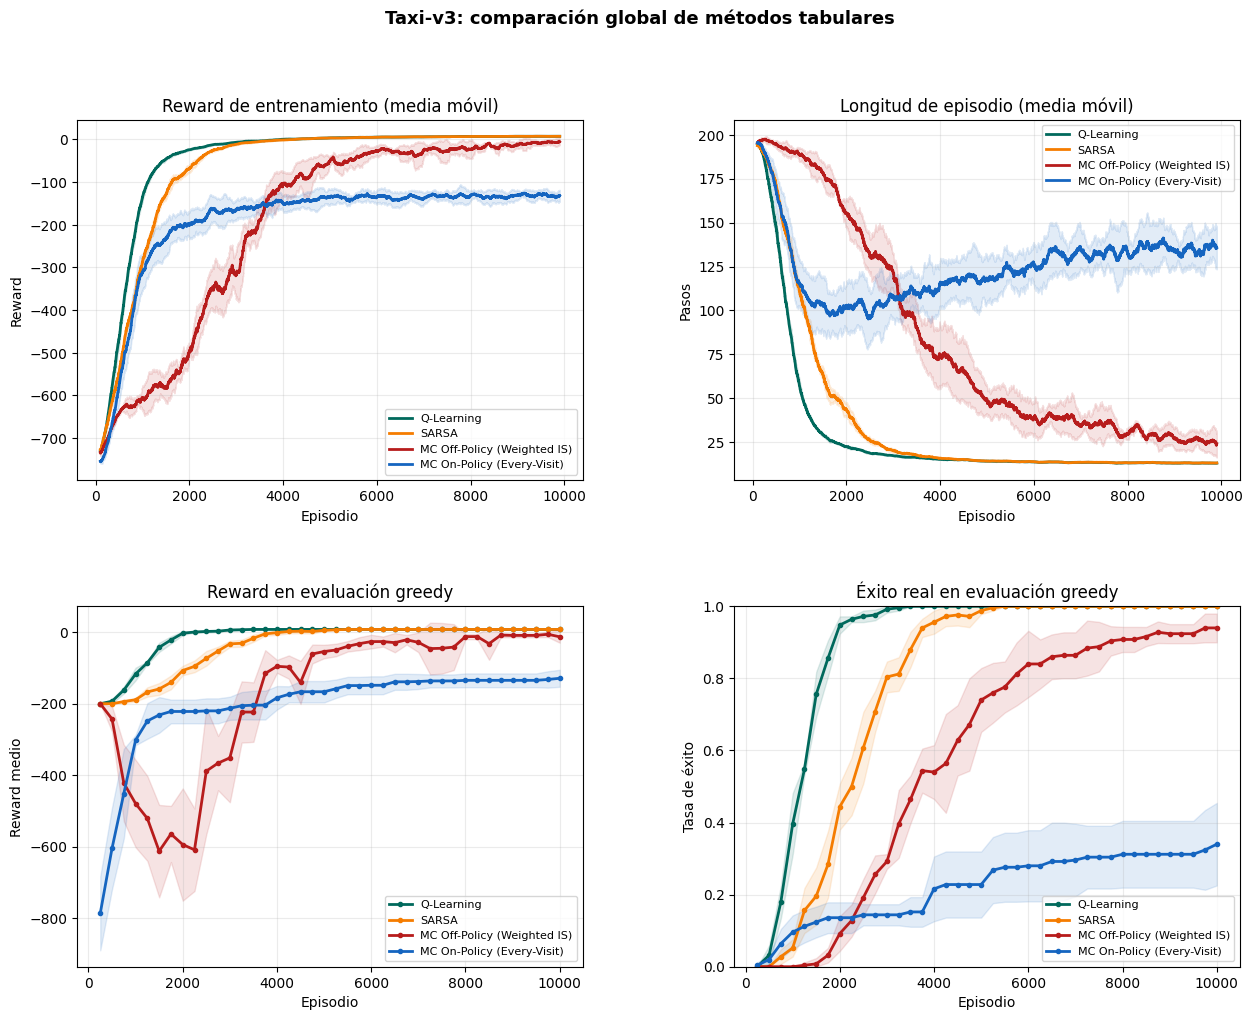

In [27]:
plot_comparative_results(all_results)

In [304]:
# Interpretación global de resultados Markdown
_all   = all_results["summary"]
_rank  = all_results["ranking"]
_label = METHOD_LABELS

_result_map = {
    "mc_on_policy":           mc_on_results,
    "mc_off_policy_weighted": mc_off_results,
    "sarsa":                  sarsa_results,
    "q_learning":             q_learning_results,
}

_rank_lines = []
for _i, _mkey in enumerate(_rank, 1):
    _ms = _all[_mkey]
    _rank_lines.append(
        f"{_i}. **{_label[_mkey]}** — "
        f"reward {_ms['final_eval_reward_mean']:.3f} ± {_ms['final_eval_reward_std_across_seeds']:.3f}, "
        f"longitud {_ms['final_eval_length_mean']:.1f} pasos, "
        f"éxito {100.0 * _ms['final_eval_success_rate_mean']:.1f}%"
    )
_ranking_text = "\n".join(_rank_lines)

_thresholds = [0.50, 0.75, 0.90, 0.99]
_thr_labels = ["≥ 50% éxito", "≥ 75% éxito", "≥ 90% éxito", "≥ 99% éxito"]

_table_rows = []
for _mkey in _rank:
    _mr = _result_map[_mkey]
    _cells = []
    for _t in _thresholds:
        _ep = convergence_episode(_mr, _mkey, _t)
        _cells.append(f"{_ep:,}" if _ep else "—")
    _table_rows.append(f"| {_label[_mkey]} | {' | '.join(_cells)} |")

_conv_table = (
    "| Método | " + " | ".join(_thr_labels) + " |\n"
    "|---|:---:|:---:|:---:|:---:|\n"
    + "\n".join(_table_rows)
)

_best  = _all[_rank[0]]
_worst = _all[_rank[-1]]
_gap_r = _best["final_eval_reward_mean"]  - _worst["final_eval_reward_mean"]
_gap_l = _worst["final_eval_length_mean"] - _best["final_eval_length_mean"]
_gap_s = 100.0 * (_best["final_eval_success_rate_mean"] - _worst["final_eval_success_rate_mean"])
_td_gap = _all["q_learning"]["final_eval_reward_mean"] - _all["sarsa"]["final_eval_reward_mean"]

_pos_reward = {}
for _mkey in _rank:
    _curve = _result_map[_mkey]["curves"][_mkey]
    _pos_ep = next((int(ep) for ep, reward in zip(_curve["eval_episodes"], _curve["eval_reward_mean"]) if reward > 0.0), None)
    _pos_reward[_mkey] = f"episodio {_pos_ep:,}" if _pos_ep else "no alcanzado en el experimento"

display(Markdown(f"""
## Conclusiones globales

### Ranking final — evaluación greedy ({config_obj.final_eval_episodes} episodios × {len(config_obj.seeds)} semillas)

{_ranking_text}

---

### Velocidad de convergencia

Primer episodio en que la evaluación greedy supera cada umbral de tasa de éxito (`—` = no alcanzado en el experimento):

{_conv_table}

---

### Lectura comparativa del gráfico

**1. Velocidad de aprendizaje.**
El gráfico separa con claridad dos regímenes. `Q-Learning` es el método más rápido: su reward greedy se vuelve positivo en el **{_pos_reward['q_learning']}**, supera el **90%** de éxito en el episodio **2,000** y alcanza el **99%** en **3,000**.
`SARSA` sigue el mismo patrón con un retraso moderado: reward positivo en el **{_pos_reward['sarsa']}**, **90%** de éxito en **3,750** y **99%** en **5,250**. Ambos métodos TD reducen también la longitud media de episodio hasta aproximadamente **13 pasos**, mientras que los métodos Monte Carlo permanecen mucho más tiempo en regímenes de trayectorias largas.

**2. Eficiencia de la política final.**
En la parte final de las curvas, `Q-Learning` y `SARSA` convergen hacia políticas prácticamente óptimas: reward positivo, **100%** de éxito y longitudes medias de **13.2–13.3 pasos**.
`MC Off-Policy (Weighted IS)` termina con **95.2%** de éxito, pero una longitud media de **23.2 pasos**, suficiente para mantener el reward en terreno negativo.
`MC On-Policy (Every-Visit)` queda muy rezagado: **30.4%** de éxito y **142.8 pasos** de media, por lo que no puede considerarse competitivo bajo este presupuesto de entrenamiento.

**3. Estabilidad y dispersión.**
Las bandas del gráfico y las desviaciones finales dibujan una jerarquía nítida de estabilidad. Los métodos TD presentan una dispersión mínima y prácticamente idéntica (**0.157** en ambos casos), lo que sugiere convergencia homogénea entre semillas.
`MC Off-Policy` reduce de forma sustancial la variabilidad respecto a `MC On-Policy`, pero todavía conserva una dispersión claramente superior (**5.543** frente a **16.990** en on-policy y **0.157** en TD), especialmente durante la fase transitoria del aprendizaje.

**4. Relación entre éxito y reward.**
La comparación global muestra que la tasa de éxito, por sí sola, no basta para caracterizar la calidad de una política. `MC Off-Policy` resuelve el entorno en la mayoría de episodios, pero no consigue reward positivo porque sus trayectorias siguen siendo demasiado largas.
Este punto queda visible en el panel de longitud de episodio: sólo `Q-Learning` y `SARSA` reducen de forma sistemática la duración media por debajo del umbral operativo necesario para hacer positivo el reward esperado.

---

### Síntesis comparativa

Bajo un protocolo estrictamente común, los métodos TD dominan simultáneamente en **eficiencia de muestra**, **estabilidad** y **calidad final de la política**.
Dentro de ese grupo, `Q-Learning` ocupa el primer lugar no por una ventaja final amplia, sino porque combina el mejor reward final con la convergencia más temprana; `SARSA` queda muy cerca en desempeño final, pero aprende algo más lentamente.
Dentro de Monte Carlo, `MC Off-Policy (Weighted IS)` es claramente superior a `MC On-Policy`, pero esa mejora no basta para cerrar la brecha con TD cuando la comparación incorpora reward, longitud y evaluación greedy real.
La distancia entre el mejor y el peor método es de **{_gap_r:.1f} puntos** en reward, **{_gap_l:.1f} pasos** en longitud media y **{_gap_s:.1f} pp** en tasa de éxito, diferencias demasiado grandes para atribuirlas a ruido experimental.

---

### Conclusión metodológica

Para `Taxi-v3`, la evidencia conjunta de las cuatro gráficas y de las métricas agregadas indica que el criterio decisivo no es únicamente "llegar al objetivo", sino **llegar de forma corta, estable y reproducible**.
Desde esa perspectiva, `Q-Learning` ofrece la mejor solución global, `SARSA` constituye una alternativa muy cercana y más conservadora, `MC Off-Policy` aprende una política razonable pero todavía ineficiente, y `MC On-Policy` resulta insuficiente para este entorno con el presupuesto de entrenamiento utilizado.
"""))



## Conclusiones globales

### Ranking final — evaluación greedy (200 episodios × 5 semillas)

1. **Q-Learning** — reward 7.788 ± 0.157, longitud 13.2 pasos, éxito 100.0%
2. **SARSA** — reward 7.722 ± 0.157, longitud 13.3 pasos, éxito 100.0%
3. **MC Off-Policy (Weighted IS)** — reward -4.953 ± 5.543, longitud 23.2 pasos, éxito 95.2%
4. **MC On-Policy (Every-Visit)** — reward -136.422 ± 16.990, longitud 142.8 pasos, éxito 30.4%

---

### Velocidad de convergencia

Primer episodio en que la evaluación greedy supera cada umbral de tasa de éxito (`—` = no alcanzado en el experimento):

| Método | ≥ 50% éxito | ≥ 75% éxito | ≥ 90% éxito | ≥ 99% éxito |
|---|:---:|:---:|:---:|:---:|
| Q-Learning | 1,250 | 1,500 | 2,000 | 3,000 |
| SARSA | 2,250 | 3,000 | 3,750 | 5,250 |
| MC Off-Policy (Weighted IS) | 3,750 | 5,250 | 7,750 | — |
| MC On-Policy (Every-Visit) | — | — | — | — |

---

### Lectura comparativa del gráfico

**1. Velocidad de aprendizaje.**
El gráfico separa con claridad dos regímenes. `Q-Learning` es el método más rápido: su reward greedy se vuelve positivo en el **episodio 2,250**, supera el **90%** de éxito en el episodio **2,000** y alcanza el **99%** en **3,000**.
`SARSA` sigue el mismo patrón con un retraso moderado: reward positivo en el **episodio 4,250**, **90%** de éxito en **3,750** y **99%** en **5,250**. Ambos métodos TD reducen también la longitud media de episodio hasta aproximadamente **13 pasos**, mientras que los métodos Monte Carlo permanecen mucho más tiempo en regímenes de trayectorias largas.

**2. Eficiencia de la política final.**
En la parte final de las curvas, `Q-Learning` y `SARSA` convergen hacia políticas prácticamente óptimas: reward positivo, **100%** de éxito y longitudes medias de **13.2–13.3 pasos**.
`MC Off-Policy (Weighted IS)` termina con **95.2%** de éxito, pero una longitud media de **23.2 pasos**, suficiente para mantener el reward en terreno negativo.
`MC On-Policy (Every-Visit)` queda muy rezagado: **30.4%** de éxito y **142.8 pasos** de media, por lo que no puede considerarse competitivo bajo este presupuesto de entrenamiento.

**3. Estabilidad y dispersión.**
Las bandas del gráfico y las desviaciones finales dibujan una jerarquía nítida de estabilidad. Los métodos TD presentan una dispersión mínima y prácticamente idéntica (**0.157** en ambos casos), lo que sugiere convergencia homogénea entre semillas.
`MC Off-Policy` reduce de forma sustancial la variabilidad respecto a `MC On-Policy`, pero todavía conserva una dispersión claramente superior (**5.543** frente a **16.990** en on-policy y **0.157** en TD), especialmente durante la fase transitoria del aprendizaje.

**4. Relación entre éxito y reward.**
La comparación global muestra que la tasa de éxito, por sí sola, no basta para caracterizar la calidad de una política. `MC Off-Policy` resuelve el entorno en la mayoría de episodios, pero no consigue reward positivo porque sus trayectorias siguen siendo demasiado largas.
Este punto queda visible en el panel de longitud de episodio: sólo `Q-Learning` y `SARSA` reducen de forma sistemática la duración media por debajo del umbral operativo necesario para hacer positivo el reward esperado.

---

### Síntesis comparativa

Bajo un protocolo estrictamente común, los métodos TD dominan simultáneamente en **eficiencia de muestra**, **estabilidad** y **calidad final de la política**.
Dentro de ese grupo, `Q-Learning` ocupa el primer lugar no por una ventaja final amplia, sino porque combina el mejor reward final con la convergencia más temprana; `SARSA` queda muy cerca en desempeño final, pero aprende algo más lentamente.
Dentro de Monte Carlo, `MC Off-Policy (Weighted IS)` es claramente superior a `MC On-Policy`, pero esa mejora no basta para cerrar la brecha con TD cuando la comparación incorpora reward, longitud y evaluación greedy real.
La distancia entre el mejor y el peor método es de **144.2 puntos** en reward, **129.6 pasos** en longitud media y **69.6 pp** en tasa de éxito, diferencias demasiado grandes para atribuirlas a ruido experimental.

---

### Conclusión metodológica

Para `Taxi-v3`, la evidencia conjunta de las cuatro gráficas y de las métricas agregadas indica que el criterio decisivo no es únicamente "llegar al objetivo", sino **llegar de forma corta, estable y reproducible**.
Desde esa perspectiva, `Q-Learning` ofrece la mejor solución global, `SARSA` constituye una alternativa muy cercana y más conservadora, `MC Off-Policy` aprende una política razonable pero todavía ineficiente, y `MC On-Policy` resulta insuficiente para este entorno con el presupuesto de entrenamiento utilizado.


## Diferencias respecto a la versión v2

Esta implementación se diferencia de `B-MC_v2.ipynb` en varios puntos importantes:

- En `v2` se comparaban los métodos principalmente a partir de curvas de entrenamiento. En `v3` la comparación decisiva se hace con evaluación greedy separada de la exploración.
- En `v2` el éxito se interpretaba de forma indirecta. En `v3` se usa la señal real del entorno: éxito solo cuando el episodio termina por `terminated`.
- En `v2` Monte Carlo off-policy no dejaba explicitada de forma robusta la probabilidad `b(a|s)` usada en importance sampling. En `v3` esa probabilidad se guarda en cada transición y se reutiliza al actualizar.
- En `v2` no había una igualdad experimental tan explícita entre algoritmos. En `v3` todos comparten exactamente las mismas semillas, episodios, `gamma`, planificación de `epsilon`, frecuencia de evaluación y criterio de resumen.
- En `v2` la narrativa final se apoyaba sobre todo en la inspección visual de las gráficas. En `v3` cada afirmación cuantitativa se apoya en métricas agregadas sobre varias semillas y en una tabla final comparativa.
- En `v2` el notebook estaba centrado solo en Monte Carlo. En `v3` primero se valida Monte Carlo y después se compara de forma justa con `SARSA` y `Q-Learning` bajo el mismo protocolo.
- En `v3` también se añaden gráficas parciales por algoritmo para entender su dinámica antes de pasar a la comparación global.
